<a href="https://colab.research.google.com/github/Rasya-ai-web/Machine-Learning-Lab/blob/main/ML_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment: Dimensionality Reduction Using PCA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Load Iris dataset

In [4]:

df = pd.read_csv("iris_300.csv")
iris = load_iris()

X = iris.data
y = iris.target


df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df['Target'] = y



np.random.seed(42)

df_extra = df.copy()


for column in iris.feature_names:
    df_extra[column] = (
        df_extra[column] +
        np.random.normal(0, 0.1, len(df_extra))
    )


df_300 = pd.concat([df, df_extra], ignore_index=True)

X = df_300[iris.feature_names]
y = df_300['Target']

print("Dataset loaded successfully!")
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of samples: 300
Number of features: 4


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures standardized successfully!")


Features standardized successfully!


In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [7]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

pca_df['Target'] = y.values

print("\nPCA applied successfully!")

print("\nOriginal dimensions:", X.shape)
print("Reduced dimensions:", X_pca.shape)

# Display explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Preserved:",
      sum(pca.explained_variance_ratio_) * 100, "%")


PCA applied successfully!

Original dimensions: (300, 4)
Reduced dimensions: (300, 2)

Explained Variance Ratio:
[0.72943842 0.22431561]

Total Variance Preserved: 95.37540262946831 %


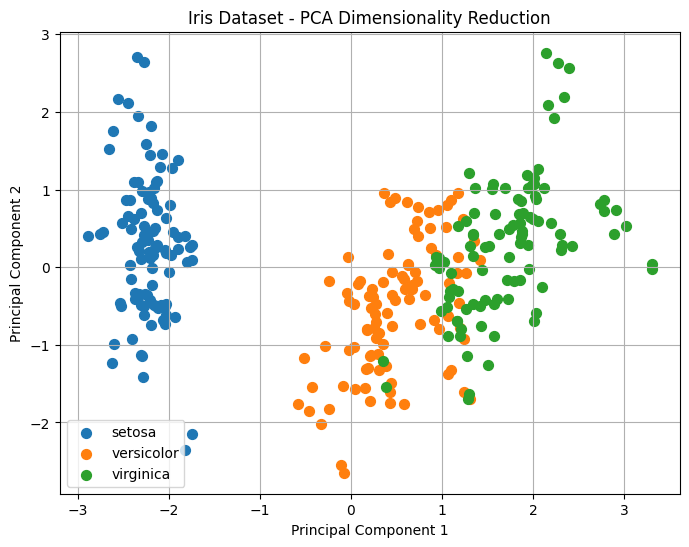


PCA dimensionality reduction completed successfully!


In [8]:
plt.figure(figsize=(8, 6))

for target, name in zip(
    [0, 1, 2],
    iris.target_names
):
    plt.scatter(
        pca_df.loc[pca_df['Target'] == target,
                   'Principal Component 1'],
        pca_df.loc[pca_df['Target'] == target,
                   'Principal Component 2'],
        label=name,
        s=50
    )

plt.title("Iris Dataset - PCA Dimensionality Reduction")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

# Stop
print("\nPCA dimensionality reduction completed successfully!")